# 📓 Notebook 8 — FY25-26 Out-of-Sample Test + Interactive Hedging Visualizer

## What this notebook does

1. Downloads **fresh FY25-26 market data** via yfinance (Apr 2025 → Apr 2026)
   - This data was **never seen during training** (train ended Dec 2023, val ended Mar 2025)
   - FY25-26 contains a genuine mixed regime: energy bull (oil >$100), tariff-driven sell-offs,
     Middle East geopolitical spikes, FTSE sector rotation
2. Runs the NB7 model on this new data — true out-of-sample test
3. Produces an **interactive multi-panel hedging visualization** showing:
   - Price path with regime annotations
   - Option positions opened/closed at each step
   - Portfolio delta over time (the key metric — should stay near 0)
   - Portfolio value vs BS baseline vs buy-and-hold
   - Action heatmap (what the agent did at each timestep)
   - Greeks exposure (vega, gamma) over the episode

**This is the most honest test** — completely fresh data, no hyperparameter tuning allowed.

In [3]:
import subprocess, sys
for p in ["yfinance","gymnasium","stable-baselines3[extra]",
           "numpy","pandas","scipy","matplotlib","seaborn","tqdm","torch"]:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",p])

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import yfinance as yf
import torch
from scipy.stats import norm as spn
from tqdm.notebook import tqdm

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")
if not os.path.exists(ROOT): ROOT = os.path.abspath(".")

PATHS = {
    "processed":   os.path.join(ROOT, "data", "processed"),
    "models_nb7":  os.path.join(ROOT, "models", "nb7"),
    "models_nb6":  os.path.join(ROOT, "models", "nb6"),
    "artifacts":   os.path.join(ROOT, "artifacts"),
    "nb8":         os.path.join(ROOT, "results", "nb8"),
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


---
## Section 1: Download FY25-26 Data (Out-of-Sample)

In [4]:
# FY25-26: April 2025 → April 2026
# This is COMPLETELY out-of-sample — model never saw this data
OOS_START = "2025-04-01"
OOS_END   = "2026-04-10"

TICKERS = {
    "BP.L":     {"class": "equities", "name": "BP plc",         "regime": "energy_bull"},
    "SHEL.L":   {"class": "equities", "name": "Shell plc",       "regime": "energy_bull"},
    "HSBA.L":   {"class": "equities", "name": "HSBC",            "regime": "mixed"},
    "LLOY.L":   {"class": "equities", "name": "Lloyds Banking",  "regime": "mixed"},
    "AZN.L":    {"class": "equities", "name": "AstraZeneca",     "regime": "defensive"},
    "RIO.L":    {"class": "equities", "name": "Rio Tinto",       "regime": "commodity"},
    "BZ=F":     {"class": "oil",      "name": "Brent Crude",     "regime": "bull"},
    "GC=F":     {"class": "gold",     "name": "Gold Futures",    "regime": "bull"},
    "GBPUSD=X": {"class": "fx",       "name": "GBP/USD",         "regime": "mixed"},
}

def compute_class_norms_from_file(processed_path, feature_cols):
    """Load training norms from the original feature file to avoid leakage."""
    feat_path = os.path.join(processed_path, "all_assets_features.csv")
    if os.path.exists(feat_path):
        df_train = pd.read_csv(feat_path, parse_dates=["date"])
        df_train = df_train[df_train["split"]=="train"]
        norms = {}
        for cls in df_train["asset_class"].unique():
            sub = df_train[df_train["asset_class"]==cls]
            fc_avail = [c for c in feature_cols if c in sub.columns]
            norms[cls] = {
                "mean": sub[fc_avail].mean().values.astype(np.float32),
                "std":  sub[fc_avail].std().values.astype(np.float32)
            }
        print(f"  Norms loaded from training data: {list(norms.keys())}")
        return norms
    return {}

def build_feature_df(ticker, asset_class, asset_name, start, end, risk_free=0.045):
    """Download OHLCV and compute all features matching the training pipeline."""
    raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if raw.empty:
        print(f"  ⚠️  {ticker}: no data")
        return None
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns = [c.lower() for c in raw.columns]
    raw = raw[["open","high","low","close","volume"]].copy()
    raw.index = pd.to_datetime(raw.index)
    raw.index.name = "date"
    raw = raw.reset_index()

    S   = raw["close"].values
    lr  = np.log(S / np.roll(S, 1)); lr[0] = 0

    # Realized vol windows
    for w in [5, 10, 21, 63]:
        raw[f"rvol_{w}d"] = pd.Series(lr).rolling(w).std().values * np.sqrt(252)
    raw["sigma"] = raw["rvol_21d"].fillna(raw["rvol_21d"].median()).clip(0.05, 3.0)

    # Returns
    raw["log_return"]     = lr
    raw["pct_return_1d"]  = np.exp(lr) - 1
    raw["pct_return_5d"]  = pd.Series(S).pct_change(5).values
    raw["pct_return_20d"] = pd.Series(S).pct_change(20).values

    # B-S Greeks (ATM, 30-day)
    T, r, sig = 30/252, risk_free, raw["sigma"].values
    d1 = (np.log(1.0) + (r + 0.5*sig**2)*T) / (sig*np.sqrt(T) + 1e-9)  # ATM: S/K=1
    d2 = d1 - sig*np.sqrt(T)
    from scipy.stats import norm as spn2
    raw["delta_call"]      = spn2.cdf(d1)
    raw["delta_put"]       = spn2.cdf(d1) - 1
    raw["gamma"]           = spn2.pdf(d1) / (S * sig * np.sqrt(T) + 1e-9)
    raw["vega"]            = S * spn2.pdf(d1) * np.sqrt(T)
    raw["theta_call"]      = (-(S * spn2.pdf(d1) * sig) / (2*np.sqrt(T)) - r*S*spn2.cdf(d2)) / 252
    raw["atm_call_price"]  = S * spn2.cdf(d1) - S * np.exp(-r*T) * spn2.cdf(d2)
    raw["atm_put_price"]   = S * np.exp(-r*T) * spn2.cdf(-d2) - S * spn2.cdf(-d1)

    # Technical indicators
    sma20 = pd.Series(S).rolling(20).mean()
    std20 = pd.Series(S).rolling(20).std()
    raw["sma_20"]         = sma20.values
    raw["price_to_sma20"] = (S / (sma20.values + 1e-8)) - 1
    raw["bband_upper"]    = (sma20 + 2*std20).values
    raw["bband_lower"]    = (sma20 - 2*std20).values
    raw["bband_pct"]      = ((S - raw["bband_lower"]) /
                              (raw["bband_upper"] - raw["bband_lower"] + 1e-8))
    delta_c = pd.Series(S).diff()
    gain = delta_c.clip(lower=0).rolling(14).mean()
    loss = (-delta_c.clip(upper=0)).rolling(14).mean()
    raw["rsi_14"] = (100 - 100/(1 + gain/(loss+1e-8))).values

    vol_ma = pd.Series(raw["volume"].values, dtype=float).rolling(20).mean()
    raw["volume_ratio"] = raw["volume"] / (vol_ma + 1e-8)

    # Regime (trending vs mean-reverting)
    raw["regime"] = np.where(
        np.abs(raw["pct_return_20d"]) > raw["rvol_21d"] / np.sqrt(12), 1, 0)

    raw["symbol"]      = ticker
    raw["asset_class"] = asset_class
    raw["asset_name"]  = asset_name
    raw["split"]       = "oos"  # out-of-sample marker

    # Drop warm-up rows
    raw = raw.iloc[63:].reset_index(drop=True)
    return raw.ffill().fillna(0)


print(f"Downloading FY25-26 data ({OOS_START} → {OOS_END})...")
oos_frames = []
for ticker, meta in TICKERS.items():
    df_t = build_feature_df(ticker, meta["class"], meta["name"], OOS_START, OOS_END)
    if df_t is not None and len(df_t) >= 63:
        oos_frames.append(df_t)
        print(f"  ✅ {ticker:12s} {len(df_t):4d} rows  "
              f"{df_t['date'].iloc[0].date()} → {df_t['date'].iloc[-1].date()}  "
              f"price: {df_t['close'].iloc[0]:.2f} → {df_t['close'].iloc[-1]:.2f} "
              f"({(df_t['close'].iloc[-1]/df_t['close'].iloc[0]-1)*100:+.1f}%)")
    else:
        print(f"  ⚠️  {ticker}: insufficient data")

oos_df = pd.concat(oos_frames, ignore_index=True)
oos_df.to_csv(os.path.join(PATHS["nb8"], "oos_features.csv"), index=False)
print(f"\n✅ OOS dataset: {len(oos_df):,} rows, {oos_df['symbol'].nunique()} symbols")

  ✅ BP.L          195 rows  2025-07-03 → 2026-04-09  price: 378.59 → 580.50 (+53.3%)
  ✅ SHEL.L        195 rows  2025-07-03 → 2026-04-09  price: 2619.75 → 3448.50 (+31.6%)
  ✅ HSBA.L        195 rows  2025-07-03 → 2026-04-09  price: 884.36 → 1333.60 (+50.8%)
  ✅ LLOY.L        195 rows  2025-07-03 → 2026-04-09  price: 75.85 → 100.62 (+32.7%)
  ✅ AZN.L         195 rows  2025-07-03 → 2026-04-09  price: 10202.25 → 15276.00 (+49.7%)
  ✅ RIO.L         194 rows  2025-07-03 → 2026-04-09  price: 4293.85 → 7248.00 (+68.8%)
  ✅ BZ=F          195 rows  2025-07-02 → 2026-04-09  price: 69.11 → 95.92 (+38.8%)
  ✅ GC=F          195 rows  2025-07-02 → 2026-04-09  price: 3348.00 → 4792.20 (+43.1%)
  ✅ GBPUSD=X      202 rows  2025-07-01 → 2026-04-10  price: 1.37 → 1.34 (-2.2%)

✅ OOS dataset: 1,761 rows, 9 symbols


---
## Section 2: Load Model + Run OOS Episodes with Full Trace

In [5]:
FEATURE_COLS = [c for c in [
    "log_return","pct_return_1d","pct_return_5d","pct_return_20d",
    "rvol_5d","rvol_10d","rvol_21d","rvol_63d",
    "delta_call","delta_put","gamma","vega","theta_call",
    "atm_call_price","atm_put_price",
    "price_to_sma20","bband_pct","rsi_14","volume_ratio","regime"
] if c in oos_df.columns]

# Load class norms from TRAINING data (critical — no leakage)
class_norms = compute_class_norms_from_file(PATHS["processed"], FEATURE_COLS)

# Load NB7 model (or NB6 fallback)
model_path = os.path.join(PATHS["models_nb7"], "best_model")
if not os.path.exists(model_path + ".zip"):
    model_path = os.path.join(PATHS["models_nb6"], "best_model")
    print("Using NB6 best model (NB7 not found)")
else:
    print("Using NB7 best model")

model = PPO.load(model_path, device=DEVICE)
MODEL_OBS_DIM = model.policy.observation_space.shape[0]
print(f"Model obs dim: {MODEL_OBS_DIM}")


def normalize_features(raw_feat, asset_class, class_norms, feature_cols):
    if asset_class not in class_norms: return raw_feat
    mu  = class_norms[asset_class]["mean"]
    std = class_norms[asset_class]["std"]
    n   = min(len(raw_feat), len(mu))
    out = raw_feat.copy()
    out[:n] = np.clip((raw_feat[:n]-mu[:n])/(std[:n]+1e-8), -5, 5)
    return out


def run_episode_trace(model, df_ep, feature_cols, class_norms,
                       model_obs_dim, risk_free=0.045):
    """
    Run one episode on df_ep and return a FULL trace for visualization:
    price, delta, positions, PnL, actions, Greeks, option values at each step.
    """
    FRAC  = 0.1
    CASH0 = 10_000.0
    MAX_U = 20
    TC    = 0.001

    cash = CASH0; lc=sc=lp=sp=up=0; lco=lpo=0
    pnl_h=[]; delta_h=[]; port_h=[CASH0]; act_h=[]
    price_h=[]; vol_h=[]; call_h=[]; put_h=[]
    pos_h=[]; gamma_h=[]; vega_h=[]; theta_h=[]
    bs_cash=CASH0; bs_delta=0.0; bs_pvs=[CASH0]; bsh_pnl=[]
    bah_h=[CASH0]  # buy-and-hold

    # BS: sell 1 ATM call at open
    S0   = float(df_ep.iloc[0]["close"])
    cp0  = float(df_ep.iloc[0]["atm_call_price"])
    bs_cash += cp0*(1-TC)
    bah_shares = CASH0 / S0

    # Portfolio state for obs
    step = 0

    def get_prices(row):
        S   = float(row["close"])
        sig = max(float(row.get("sigma",0.20)), 0.05)
        T   = 30/252
        cp  = float(row.get("atm_call_price", S*sig*np.sqrt(T)*0.4))
        pp  = float(row.get("atm_put_price",  S*sig*np.sqrt(T)*0.38))
        dc  = float(row.get("delta_call", 0.5))
        dp  = dc-1.0
        gm  = float(row.get("gamma", 0.01))
        vg  = float(row.get("vega", S*0.1))
        th  = float(row.get("theta_call", -0.05))
        return S,cp,pp,dc,dp,gm,vg,th

    def port_val(S,cp,pp):
        return cash + lc*cp - sc*cp + lp*pp - sp*pp + up*S*FRAC

    def build_obs(row, step, recent_acts):
        S,cp,pp,dc,dp,gm,vg,th = get_prices(row)
        raw = np.array([row[c] if c in row.index and not pd.isna(row[c]) else 0.0
                        for c in feature_cols], dtype=np.float32)
        ac  = row.get("asset_class", "equities")
        mkt = normalize_features(raw, ac, class_norms, feature_cols)

        pv  = port_val(S,cp,pp)
        pd_ = lc*dc-sc*dc+lp*dp-sp*dp+up*FRAC
        hg  = (-pd_/FRAC)-up
        tp  = lc+sc+lp+sp
        rec = np.array(recent_acts[-20:]) if recent_acts else np.array([])
        rbu = (rec==5).mean() if len(rec) else 0.0
        rsu = (rec==6).mean() if len(rec) else 0.0

        pf = np.array([lc/5,sc/5,lp/5,sp/5,up/MAX_U,
                       cash/CASH0-1, np.clip((pv-CASH0)/CASH0,-2,2),
                       np.clip(pd_/5,-3,3), step/len(df_ep),
                       tp/20, np.clip(hg/10,-3,3),
                       (0),rbu,rsu], dtype=np.float32)

        obs = np.nan_to_num(np.concatenate([mkt,pf]),nan=0,posinf=5,neginf=-5)
        # Handle obs dim mismatch
        if len(obs) > model_obs_dim: obs = obs[:model_obs_dim]
        elif len(obs) < model_obs_dim: obs = np.pad(obs,(0,model_obs_dim-len(obs)))
        return obs

    recent_acts = []
    nonlocal_cash = [cash]; nonlocal_state = [lc,sc,lp,sp,up,lco,lpo]

    for idx, (_, row) in enumerate(df_ep.iterrows()):
        S,cp,pp,dc,dp,gm,vg,th = get_prices(row)

        obs  = build_obs(row, idx, recent_acts)
        act, _ = model.predict(obs, deterministic=True)
        act    = int(act)
        recent_acts.append(act)

        # Execute action
        if act==1 and lc<5 and cash>=cp*(1+TC):
            cash-=cp*(1+TC); lc+=1
        elif act==2 and sc<5:
            cash+=cp*(1-TC); sc+=1
        elif act==3 and lp<5 and cash>=pp*(1+TC):
            cash-=pp*(1+TC); lp+=1
        elif act==4 and sp<5:
            cash+=pp*(1-TC); sp+=1
        elif act==5 and up<MAX_U and cash>=S*FRAC*(1+TC):
            cash-=S*FRAC*(1+TC); up+=1
        elif act==6 and up>=1:
            cash+=S*FRAC*(1-TC); up-=1
        elif act==7:
            cash+=lc*cp*(1-TC)-sc*cp*(1+TC)+lp*pp*(1-TC)-sp*pp*(1+TC)
            cash+=up*S*FRAC*(1-TC)
            lc=sc=lp=sp=up=0

        # BS delta hedge step
        diff = dc - bs_delta
        bs_cash -= diff*S*(1+TC*abs(diff))
        bs_delta = dc
        bs_pv = bs_cash + bs_delta*S - cp
        bs_pvs.append(bs_pv)

        # Record everything
        pv = port_val(S,cp,pp)
        pd_= lc*dc-sc*dc+lp*dp-sp*dp+up*FRAC

        price_h.append(S)
        act_h.append(act)
        delta_h.append(pd_)
        port_h.append(pv)
        call_h.append(cp)
        put_h.append(pp)
        vol_h.append(float(row.get("sigma",0.2)))
        pos_h.append({"lc":lc,"sc":sc,"lp":lp,"sp":sp,"up":up})
        gamma_h.append(gm * (lc-sc+lp-sp))
        vega_h.append(vg * (lc-sc+lp-sp))
        theta_h.append(th * max(lc+sc+lp+sp,0))
        if idx>0: pnl_h.append((port_h[-1]-port_h[-2])/CASH0)
        bah_h.append(bah_shares * S)

    return {
        "price":   np.array(price_h),
        "delta":   np.array(delta_h),
        "port":    np.array(port_h[1:]),
        "bs_port": np.array(bs_pvs[1:]),
        "bah":     np.array(bah_h[1:]),
        "actions": np.array(act_h),
        "calls":   np.array(call_h),
        "puts":    np.array(put_h),
        "vol":     np.array(vol_h),
        "positions":pos_h,
        "gamma":   np.array(gamma_h),
        "vega":    np.array(vega_h),
        "theta":   np.array(theta_h),
        "pnl":     np.array(pnl_h),
        "dates":   df_ep["date"].values,
        "symbol":  df_ep["symbol"].iloc[0],
        "asset_class": df_ep["asset_class"].iloc[0],
    }


# Run one episode per symbol — pick 63-day window from middle of OOS period
# to include the energy price spike around late 2025
print("Running OOS episodes...")
episodes = {}
for sym in oos_df["symbol"].unique():
    sym_df = oos_df[oos_df["symbol"]==sym].reset_index(drop=True)
    if len(sym_df) < 63: continue
    # Pick the 63-day window that includes the most volatility
    vols = [sym_df["rvol_21d"].iloc[i:i+63].mean()
            for i in range(0, len(sym_df)-63, 5)]
    best_start = np.argmax(vols) * 5
    ep_df = sym_df.iloc[best_start:best_start+63].reset_index(drop=True)
    tr    = run_episode_trace(model, ep_df, FEATURE_COLS, class_norms, MODEL_OBS_DIM)
    episodes[sym] = tr

    pnl_pct = (tr["port"][-1]-10000)/10000*100
    bs_pct  = (tr["bs_port"][-1]-10000)/10000*100
    bah_pct = (tr["bah"][-1]-10000)/10000*100
    print(f"  {sym:12s} | RL: {pnl_pct:+.2f}%  BS: {bs_pct:+.2f}%  B&H: {bah_pct:+.2f}%  "
          f"avg|Δ|: {np.abs(tr['delta']).mean():.3f}")

print(f"\n✅ {len(episodes)} OOS episodes completed")

  Norms loaded from training data: ['equities', 'oil', 'gold', 'fx']
Using NB7 best model
Model obs dim: 34
Running OOS episodes...
  BP.L         | RL: +0.01%  BS: +0.74%  B&H: +42.89%  avg|Δ|: 0.007
  SHEL.L       | RL: -0.13%  BS: +4.24%  B&H: +34.38%  avg|Δ|: 0.007
  HSBA.L       | RL: +0.01%  BS: +0.08%  B&H: +6.57%  avg|Δ|: 0.007
  LLOY.L       | RL: +0.00%  BS: +0.04%  B&H: +10.48%  avg|Δ|: 0.007
  AZN.L        | RL: -13.64%  BS: +3.55%  B&H: +9.56%  avg|Δ|: 0.093
  RIO.L        | RL: -0.03%  BS: +4.23%  B&H: +18.40%  avg|Δ|: 0.027
  BZ=F         | RL: -0.03%  BS: +0.13%  B&H: +80.02%  avg|Δ|: 0.028
  GC=F         | RL: -1.98%  BS: -0.13%  B&H: +3.90%  avg|Δ|: 0.101
  GBPUSD=X     | RL: +0.00%  BS: -0.00%  B&H: -2.03%  avg|Δ|: 0.006

✅ 9 OOS episodes completed


---
## Section 3: Interactive Hedging Visualization

Pick any symbol and see the complete step-by-step hedging story.


Plotting most volatile episode: AZN.L
💾 Saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results\nb8\hedging_viz_AZN_L.png


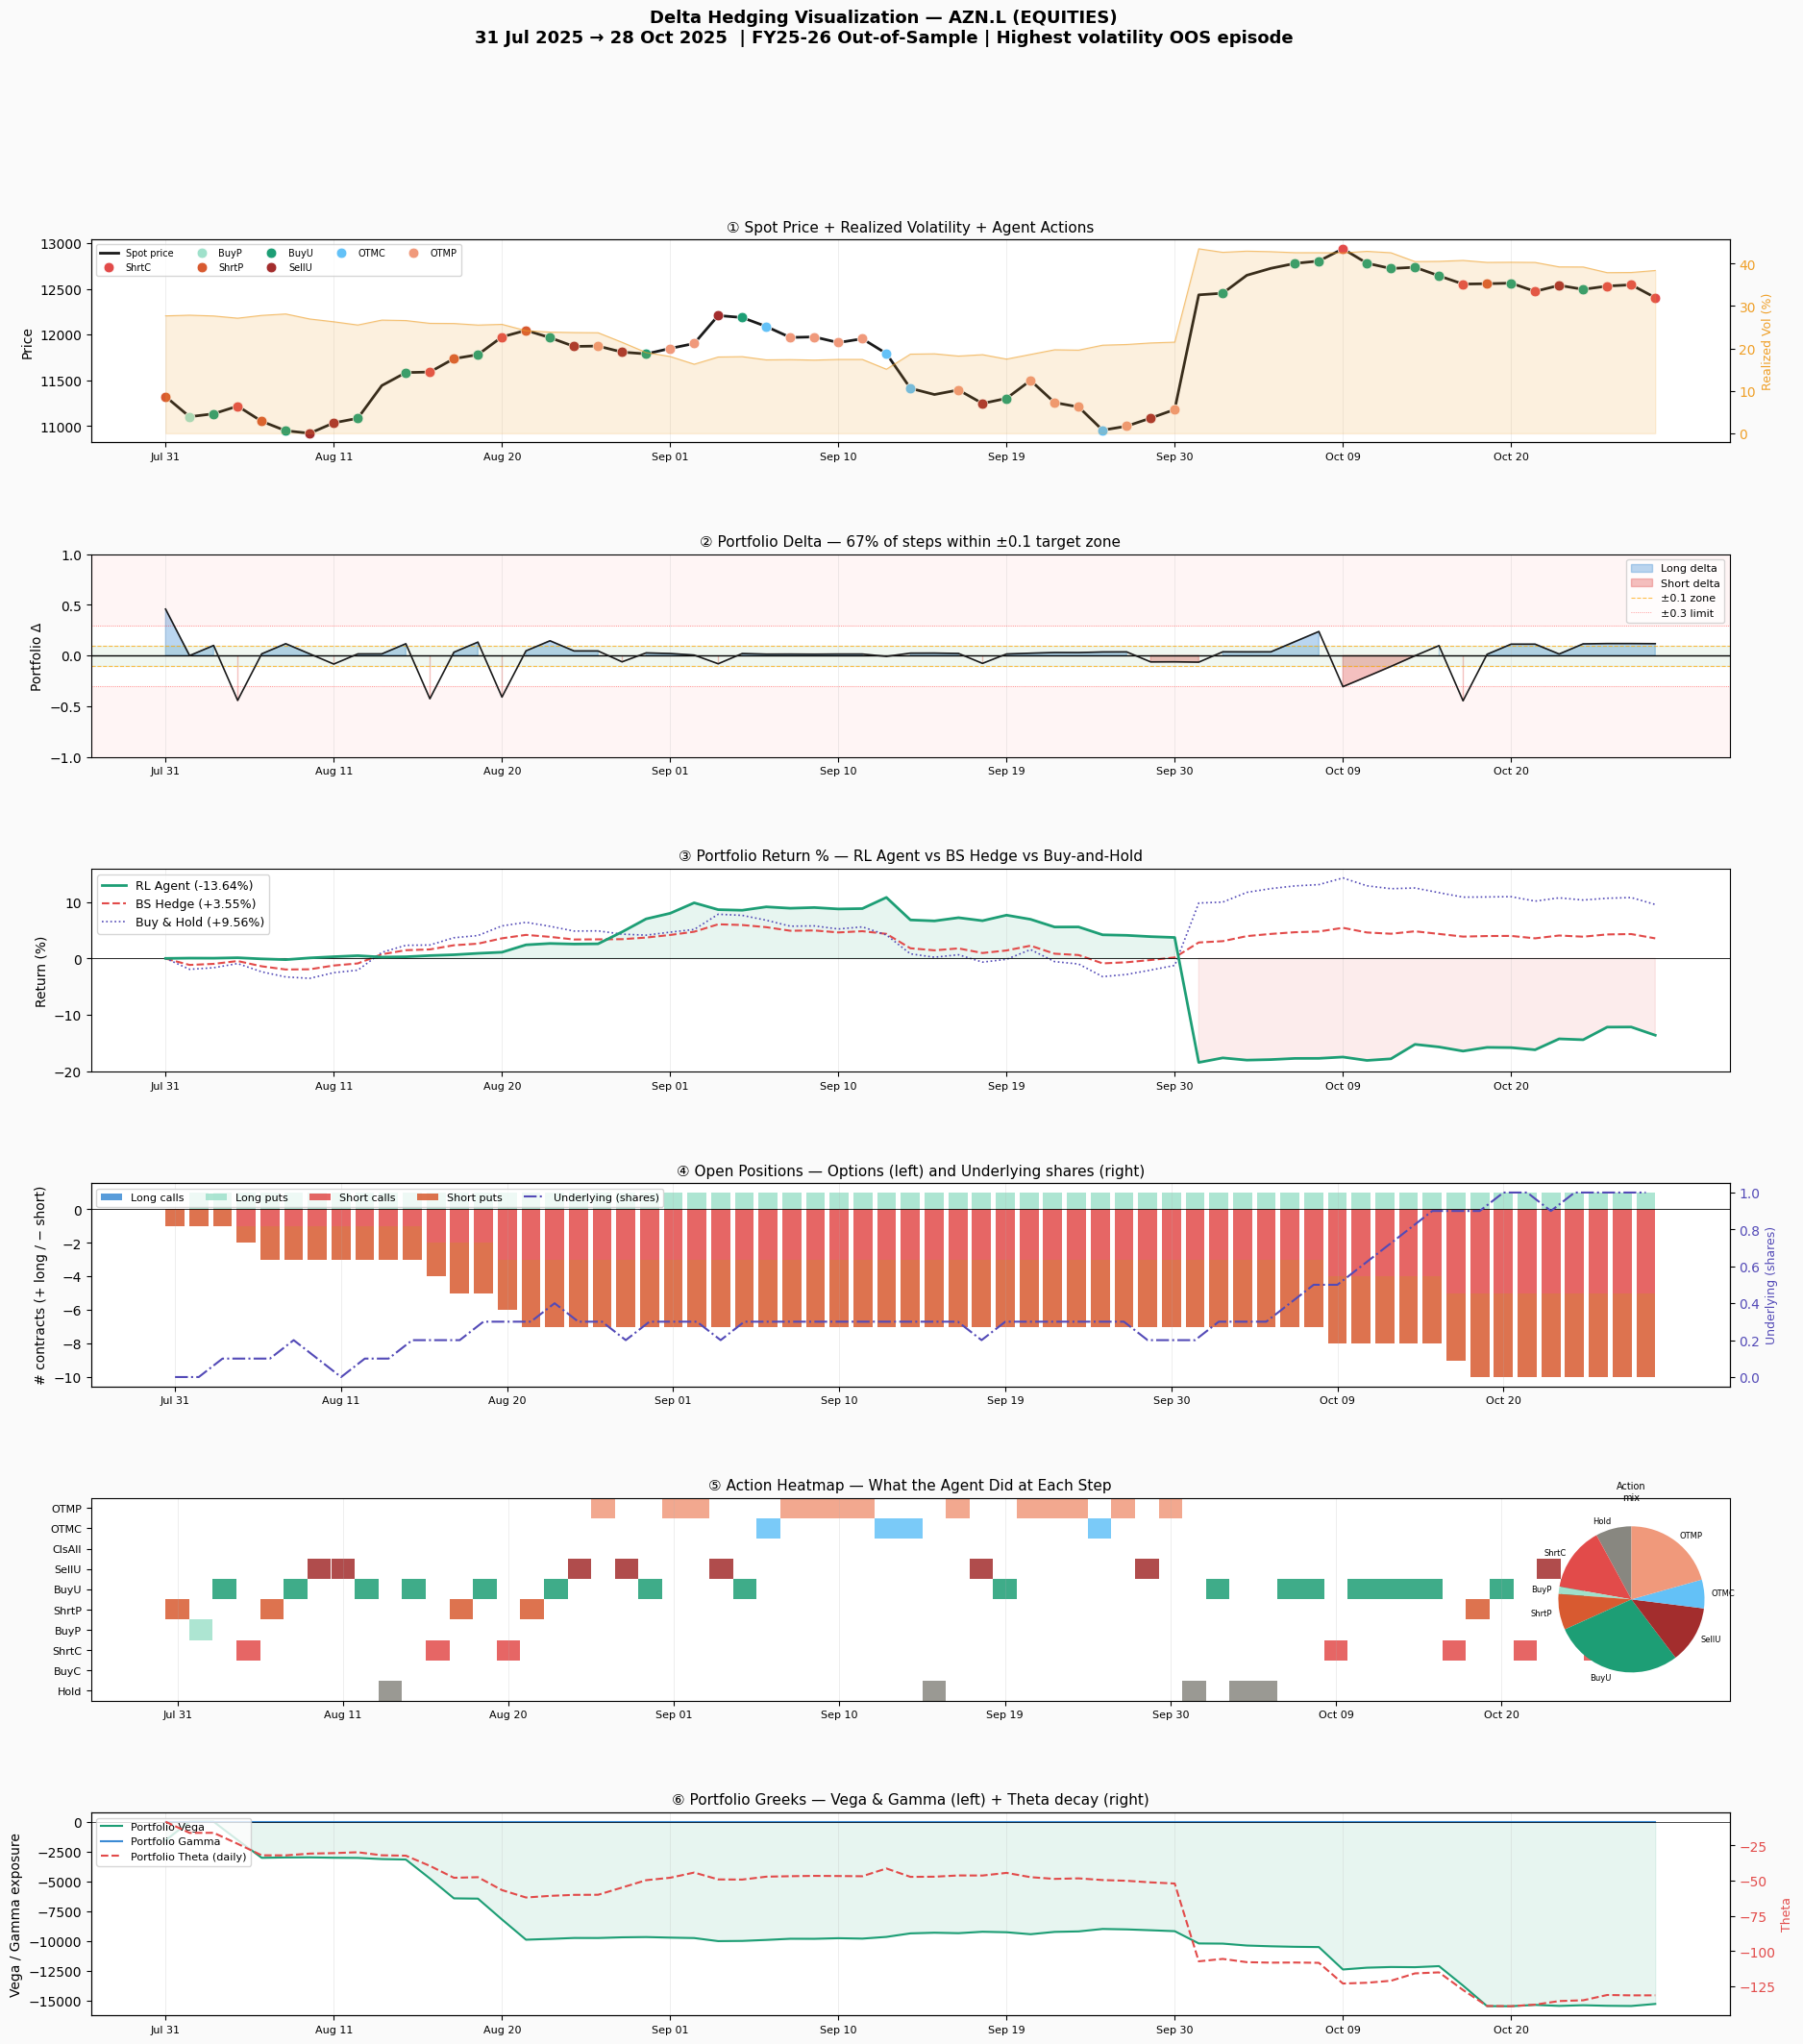

In [7]:
ACTION_NAMES = ["Hold","BuyC","ShrtC","BuyP","ShrtP",
                "BuyU","SellU","ClsAll","OTMC","OTMP"]
ACTION_COLORS = ["#888780","#3B8BD4","#E24B4A","#9FE1CB","#D85A30",
                 "#1D9E75","#A32D2D","#534AB7","#63C1F7","#F0997B"]

def plot_hedging_dashboard(tr, title="", save_path=None):
    """
    6-panel interactive hedging visualization.
    Everything is aligned on the same x-axis (trading day within episode).
    """
    steps  = np.arange(len(tr["price"]))
    dates  = pd.to_datetime(tr["dates"])
    xlabels= [d.strftime("%b %d") for d in dates]
    tick_every = max(1, len(steps)//8)
    xticks = steps[::tick_every]
    xlabs  = [xlabels[i] for i in xticks]

    fig = plt.figure(figsize=(22, 24))
    fig.patch.set_facecolor("#fafafa")
    gs  = gridspec.GridSpec(6, 1, figure=fig, hspace=0.55)
    sym = tr["symbol"]; cls = tr["asset_class"]

    fig.suptitle(
        f"Delta Hedging Visualization — {sym} ({cls.upper()})\n"
        f"{dates[0].strftime('%d %b %Y')} → {dates[-1].strftime('%d %b %Y')}  "
        f"| FY25-26 Out-of-Sample | {title}",
        fontsize=13, fontweight="bold", y=0.98)

    # ── Panel 1: Price + Realized Vol + Actions ───────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1b= ax1.twinx()

    ax1.plot(steps, tr["price"], color="#1a1a1a", linewidth=2, label="Spot price", zorder=3)
    ax1b.fill_between(steps, tr["vol"]*100, alpha=0.15, color="#EF9F27", label="RVol 21d")
    ax1b.plot(steps, tr["vol"]*100, color="#EF9F27", linewidth=0.8, alpha=0.6)

    # Scatter action dots on price line
    for a_idx, a_name, a_color in zip(range(10), ACTION_NAMES, ACTION_COLORS):
        mask = tr["actions"] == a_idx
        if mask.any() and a_idx != 0:  # skip Hold for cleanliness
            ax1.scatter(steps[mask], tr["price"][mask], c=a_color, s=60,
                         zorder=4, label=a_name, edgecolors="white", linewidth=0.5)

    ax1.set_ylabel("Price", fontsize=10); ax1b.set_ylabel("Realized Vol (%)", fontsize=9, color="#EF9F27")
    ax1.set_title("① Spot Price + Realized Volatility + Agent Actions", fontsize=11, fontweight="500")
    ax1.set_xticks(xticks); ax1.set_xticklabels(xlabs, fontsize=8)
    handles1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(handles1, labels1, fontsize=7, ncol=5, loc="upper left",
                framealpha=0.8, bbox_to_anchor=(0,1))
    ax1.grid(axis="x", alpha=0.3, linewidth=0.5)
    ax1b.tick_params(axis="y", labelcolor="#EF9F27")

    # ── Panel 2: Portfolio Delta (the KEY panel) ──────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.fill_between(steps, tr["delta"], 0,
                      where=tr["delta"]>=0, color="#3B8BD4", alpha=0.35, label="Long delta")
    ax2.fill_between(steps, tr["delta"], 0,
                      where=tr["delta"]<0,  color="#E24B4A", alpha=0.35, label="Short delta")
    ax2.plot(steps, tr["delta"], color="#1a1a1a", linewidth=1.2, zorder=3)
    ax2.axhline(0,    color="black",  linewidth=1.0, linestyle="-")
    ax2.axhline(+0.1, color="orange", linewidth=0.8, linestyle="--", alpha=0.7, label="±0.1 zone")
    ax2.axhline(-0.1, color="orange", linewidth=0.8, linestyle="--", alpha=0.7)
    ax2.axhline(+0.3, color="red",    linewidth=0.6, linestyle=":",  alpha=0.5, label="±0.3 limit")
    ax2.axhline(-0.3, color="red",    linewidth=0.6, linestyle=":",  alpha=0.5)

    # Shade danger zones
    ax2.axhspan(0.3,  2.0, alpha=0.04, color="red")
    ax2.axhspan(-2.0,-0.3, alpha=0.04, color="red")
    ax2.axhspan(-0.1, 0.1, alpha=0.06, color="green")

    pct_neutral = (np.abs(tr["delta"]) < 0.1).mean() * 100
    ax2.set_title(f"② Portfolio Delta — {pct_neutral:.0f}% of steps within ±0.1 target zone",
                   fontsize=11, fontweight="500")
    ax2.set_ylabel("Portfolio Δ", fontsize=10)
    ax2.legend(fontsize=8, loc="upper right")
    ax2.set_xticks(xticks); ax2.set_xticklabels(xlabs, fontsize=8)
    ax2.grid(axis="x", alpha=0.3, linewidth=0.5)
    ax2.set_ylim(-1.0, 1.0)

    # ── Panel 3: Portfolio Value vs BS vs Buy-and-Hold ─────────────────────
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(steps, (tr["port"]/10000-1)*100,    color="#1D9E75", linewidth=2,
              label=f"RL Agent ({(tr['port'][-1]/10000-1)*100:+.2f}%)", zorder=3)
    ax3.plot(steps, (tr["bs_port"]/10000-1)*100, color="#E24B4A", linewidth=1.5,
              linestyle="--", label=f"BS Hedge ({(tr['bs_port'][-1]/10000-1)*100:+.2f}%)")
    ax3.plot(steps, (tr["bah"]/10000-1)*100,     color="#534AB7", linewidth=1.2,
              linestyle=":",  label=f"Buy & Hold ({(tr['bah'][-1]/10000-1)*100:+.2f}%)")
    ax3.axhline(0, color="black", linewidth=0.6)
    ax3.fill_between(steps, (tr["port"]/10000-1)*100, 0,
                      where=tr["port"]>10000, color="#1D9E75", alpha=0.1)
    ax3.fill_between(steps, (tr["port"]/10000-1)*100, 0,
                      where=tr["port"]<=10000, color="#E24B4A", alpha=0.1)
    ax3.set_title("③ Portfolio Return % — RL Agent vs BS Hedge vs Buy-and-Hold",
                   fontsize=11, fontweight="500")
    ax3.set_ylabel("Return (%)", fontsize=10)
    ax3.legend(fontsize=9, loc="upper left")
    ax3.set_xticks(xticks); ax3.set_xticklabels(xlabs, fontsize=8)
    ax3.grid(axis="x", alpha=0.3, linewidth=0.5)

    # ── Panel 4: Open Positions (stacked bar) ─────────────────────────────
    ax4 = fig.add_subplot(gs[3])
    lc_arr = np.array([p["lc"] for p in tr["positions"]])
    sc_arr = np.array([p["sc"] for p in tr["positions"]])
    lp_arr = np.array([p["lp"] for p in tr["positions"]])
    sp_arr = np.array([p["sp"] for p in tr["positions"]])
    up_arr = np.array([p["up"] for p in tr["positions"]])

    ax4.bar(steps, lc_arr, label="Long calls",  color="#3B8BD4", alpha=0.85)
    ax4.bar(steps, lp_arr, bottom=lc_arr, label="Long puts",   color="#9FE1CB", alpha=0.85)
    ax4.bar(steps, -sc_arr, label="Short calls", color="#E24B4A", alpha=0.85)
    ax4.bar(steps, -sp_arr, bottom=-sc_arr, label="Short puts",  color="#D85A30", alpha=0.85)
    ax4_b = ax4.twinx()
    ax4_b.plot(steps, up_arr*0.1, color="#534AB7", linewidth=1.5,
                linestyle="-.", label="Underlying (shares)")
    ax4_b.set_ylabel("Underlying (shares)", color="#534AB7", fontsize=9)
    ax4_b.tick_params(axis="y", labelcolor="#534AB7")
    ax4.axhline(0, color="black", linewidth=0.6)
    ax4.set_title("④ Open Positions — Options (left) and Underlying shares (right)",
                   fontsize=11, fontweight="500")
    ax4.set_ylabel("# contracts (+ long / − short)", fontsize=10)
    h4, l4 = ax4.get_legend_handles_labels()
    h4b, l4b = ax4_b.get_legend_handles_labels()
    ax4.legend(h4+h4b, l4+l4b, fontsize=8, ncol=5, loc="upper left")
    ax4.set_xticks(xticks); ax4.set_xticklabels(xlabs, fontsize=8)
    ax4.grid(axis="x", alpha=0.3, linewidth=0.5)

    # ── Panel 5: Action heatmap ────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[4])
    act_matrix = np.zeros((10, len(steps)))
    for t, a in enumerate(tr["actions"]):
        act_matrix[a, t] = 1

    # Show as colored tiles
    for a_idx in range(10):
        mask = tr["actions"] == a_idx
        if mask.any():
            ax5.bar(steps[mask], np.ones(mask.sum()),
                     bottom=a_idx, color=ACTION_COLORS[a_idx],
                     alpha=0.85, width=1.0, edgecolor="none")

    ax5.set_yticks(np.arange(10)+0.5)
    ax5.set_yticklabels(ACTION_NAMES, fontsize=8)
    ax5.set_title("⑤ Action Heatmap — What the Agent Did at Each Step",
                   fontsize=11, fontweight="500")
    ax5.set_xticks(xticks); ax5.set_xticklabels(xlabs, fontsize=8)
    ax5.set_ylim(0, 10)
    ax5.grid(axis="x", alpha=0.3, linewidth=0.5)

    # Action frequency pie beside heatmap
    counts = np.bincount(tr["actions"], minlength=10)
    nonzero= [(i, counts[i]) for i in range(10) if counts[i]>0]
    pie_ax = ax5.inset_axes([0.88, 0.05, 0.12, 0.90])
    pie_ax.pie([c for _,c in nonzero],
                labels=[ACTION_NAMES[i] for i,_ in nonzero],
                colors=[ACTION_COLORS[i] for i,_ in nonzero],
                textprops={"fontsize":6}, startangle=90)
    pie_ax.set_title("Action\nmix", fontsize=7)

    # ── Panel 6: Greeks exposure ───────────────────────────────────────────
    ax6 = fig.add_subplot(gs[5])
    ax6b= ax6.twinx()
    ax6.plot(steps, tr["vega"],  color="#1D9E75", linewidth=1.5, label="Portfolio Vega")
    ax6.plot(steps, tr["gamma"], color="#3B8BD4", linewidth=1.5, label="Portfolio Gamma")
    ax6.fill_between(steps, tr["vega"], 0, alpha=0.1, color="#1D9E75")
    ax6b.plot(steps, tr["theta"], color="#E24B4A", linewidth=1.5,
               linestyle="--", label="Portfolio Theta (daily)")
    ax6b.set_ylabel("Theta", color="#E24B4A", fontsize=9)
    ax6b.tick_params(axis="y", labelcolor="#E24B4A")
    ax6.axhline(0, color="black", linewidth=0.5)
    ax6.set_title("⑥ Portfolio Greeks — Vega & Gamma (left) + Theta decay (right)",
                   fontsize=11, fontweight="500")
    ax6.set_ylabel("Vega / Gamma exposure", fontsize=10)
    h6, l6 = ax6.get_legend_handles_labels()
    h6b, l6b = ax6b.get_legend_handles_labels()
    ax6.legend(h6 + h6b, l6 + l6b, fontsize=8, loc="upper left")
    ax6.legend(h6+h6b, l6+l6b, fontsize=8, loc="upper left")
    ax6.set_xticks(xticks); ax6.set_xticklabels(xlabs, fontsize=8)
    ax6.grid(axis="x", alpha=0.3, linewidth=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"💾 Saved → {save_path}")
    plt.show()


# ── Plot the most interesting episode (highest vol = most action) ──────────
most_volatile = max(episodes, key=lambda s: np.std(episodes[s]["price"]))
print(f"\nPlotting most volatile episode: {most_volatile}")
plot_hedging_dashboard(
    episodes[most_volatile],
    title=f"Highest volatility OOS episode",
    save_path=os.path.join(PATHS["nb8"], f"hedging_viz_{most_volatile.replace('.','_')}.png")
)

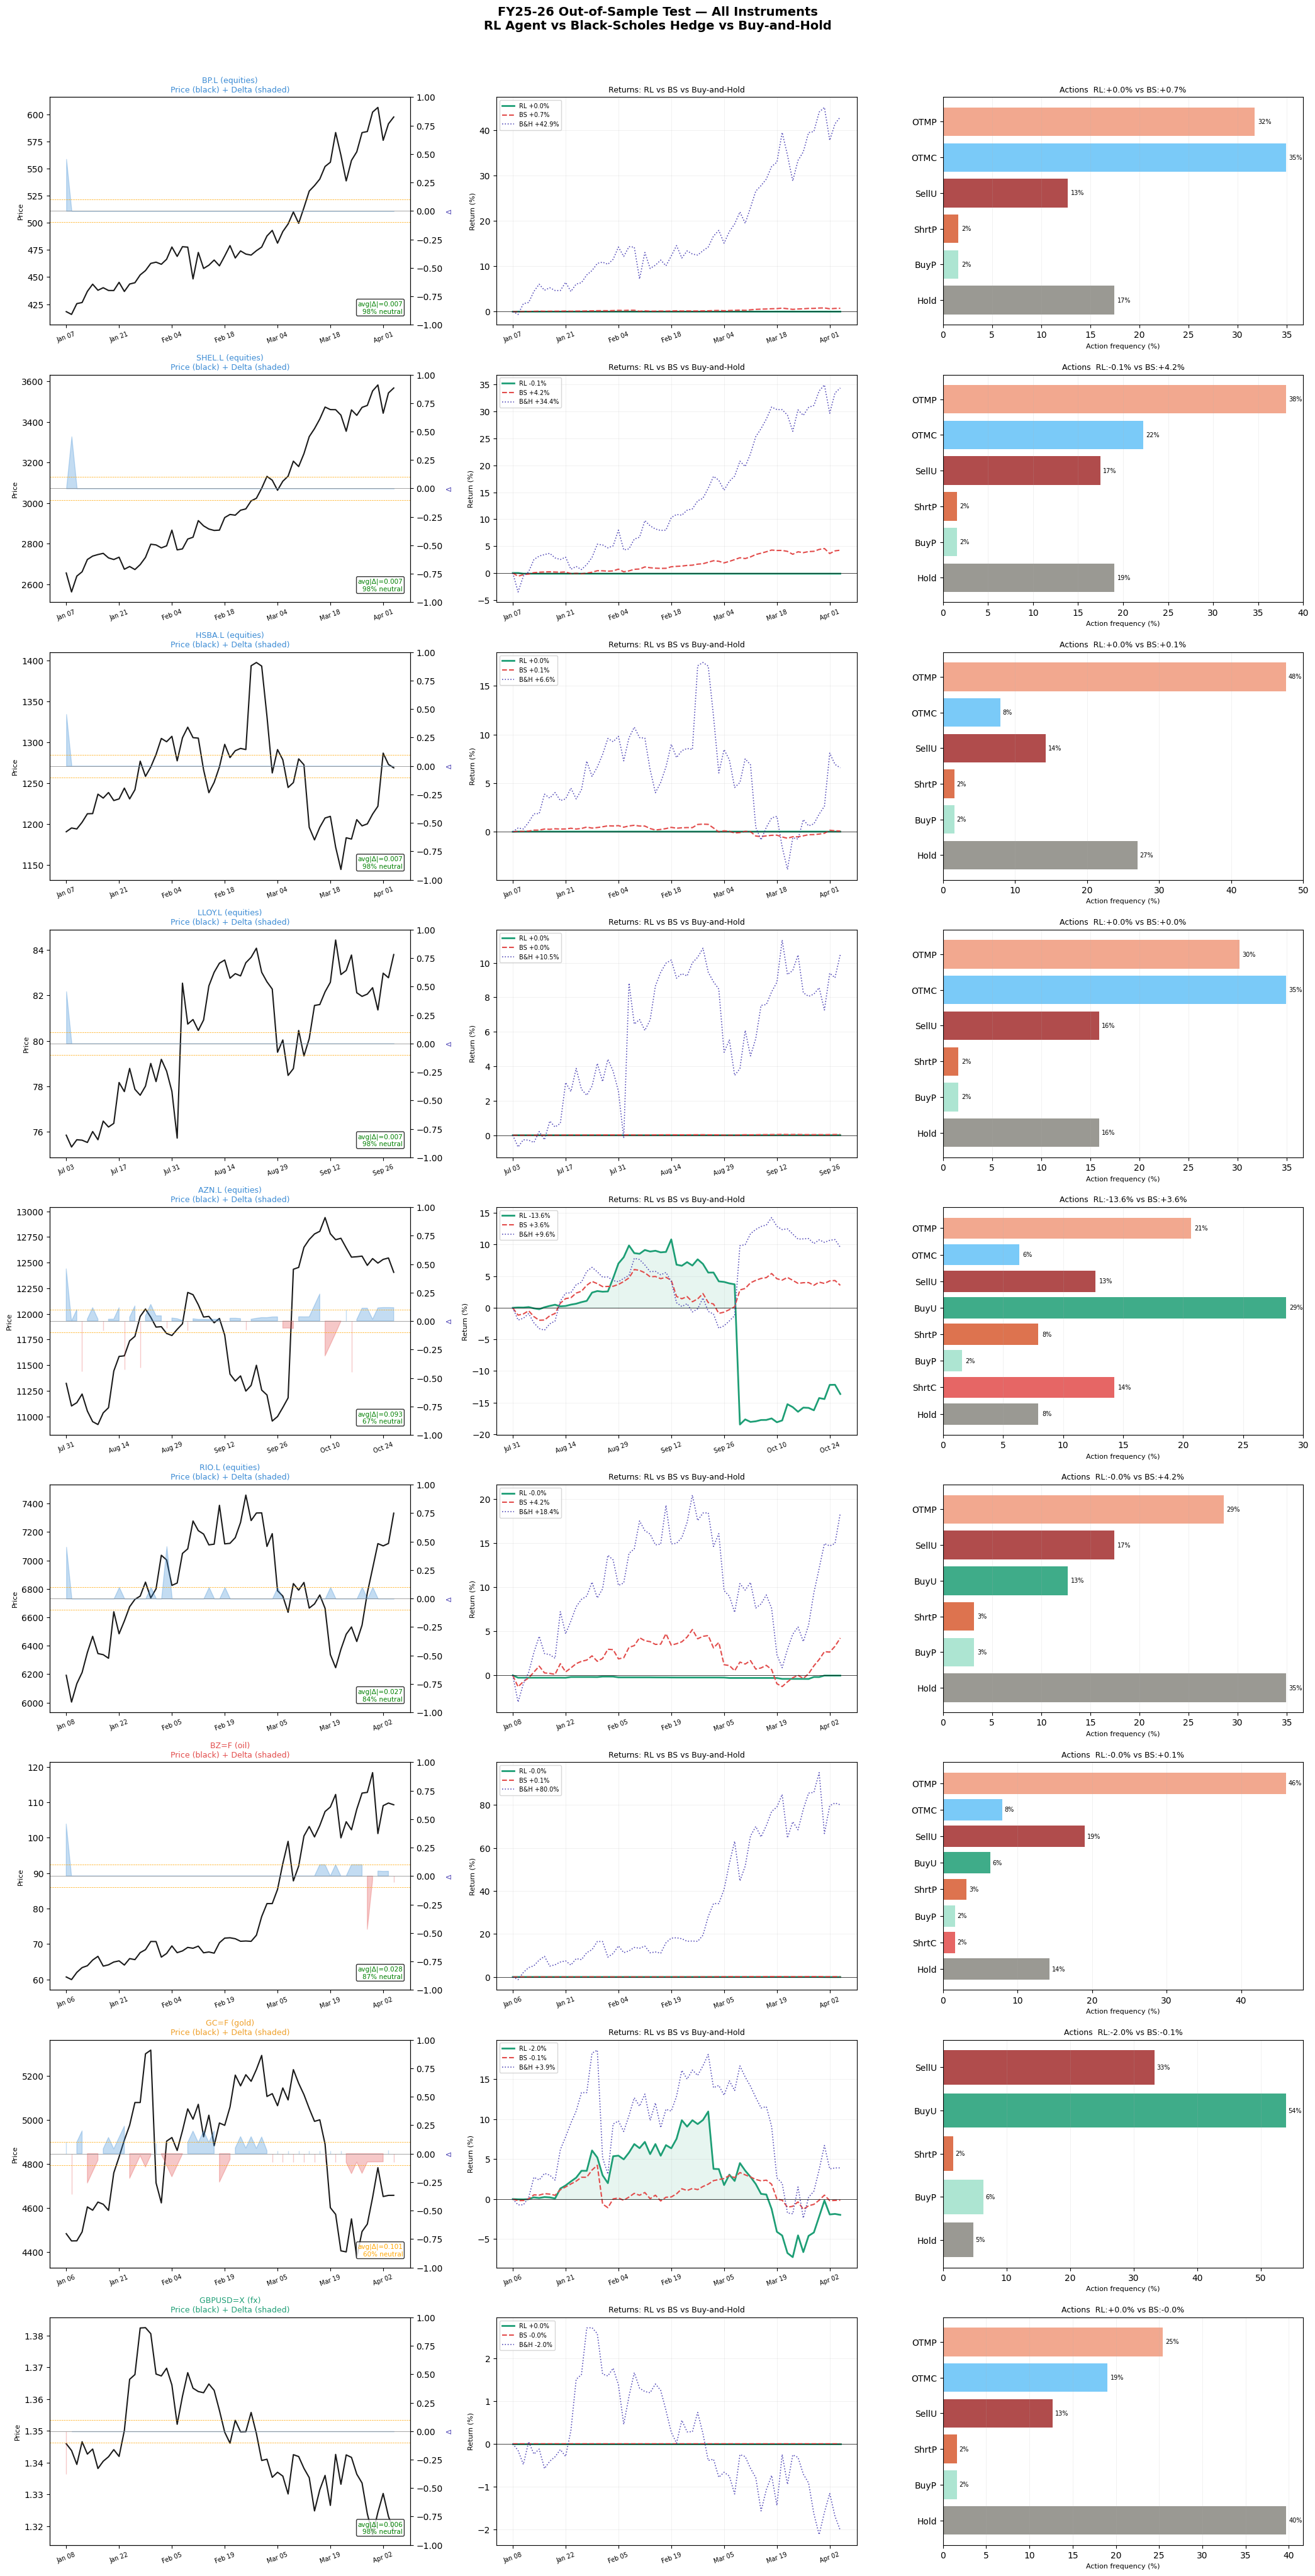

💾 All-symbol grid saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results\nb8\all_symbols_oos.png

 FY25-26 OUT-OF-SAMPLE RESULTS
  symbol    class  RL return %  BS return %  B&H return %  avg |delta|  % steps neutral  RL beats BS  RL beats B&H
    BP.L equities         0.01         0.74         42.89       0.0072             98.4        False         False
  SHEL.L equities        -0.13         4.24         34.38       0.0072             98.4        False         False
  HSBA.L equities         0.01         0.08          6.57       0.0072             98.4        False         False
  LLOY.L equities         0.00         0.04         10.48       0.0073             98.4        False         False
   AZN.L equities       -13.64         3.55          9.56       0.0929             66.7        False         False
   RIO.L equities        -0.03         4.23         18.40       0.0272             84.1        False         False
    BZ=F      oil        -0.03         0.13     

In [8]:
# ── Plot all symbols in a grid ─────────────────────────────────────────────
# Compact 3-panel version for each symbol
syms = list(episodes.keys())
n_syms = len(syms)
fig, axes = plt.subplots(n_syms, 3, figsize=(21, 4.5*n_syms))
if n_syms == 1: axes = axes.reshape(1, -1)
fig.suptitle("FY25-26 Out-of-Sample Test — All Instruments\n"
             "RL Agent vs Black-Scholes Hedge vs Buy-and-Hold",
             fontsize=14, fontweight="bold", y=1.01)

summary_rows = []

for row_idx, sym in enumerate(syms):
    tr  = episodes[sym]
    steps = np.arange(len(tr["price"]))
    dates = pd.to_datetime(tr["dates"])
    tick_every = max(1, len(steps)//6)
    xticks = steps[::tick_every]
    xlabs  = [dates[i].strftime("%b %d") for i in xticks]

    rl_ret  = (tr["port"][-1]/10000-1)*100
    bs_ret  = (tr["bs_port"][-1]/10000-1)*100
    bah_ret = (tr["bah"][-1]/10000-1)*100
    avg_d   = np.abs(tr["delta"]).mean()
    pct_n   = (np.abs(tr["delta"])<0.1).mean()*100

    cls = tr["asset_class"]
    regime_color = {"equities":"#3B8BD4","oil":"#E24B4A",
                    "gold":"#EF9F27","fx":"#1D9E75"}.get(cls, "#888780")

    # Col 1: Price + delta
    ax = axes[row_idx, 0]
    ax2 = ax.twinx()
    ax.plot(steps, tr["price"], color="#1a1a1a", linewidth=1.5)
    ax2.fill_between(steps, tr["delta"], 0,
                      where=tr["delta"]>=0, color="#3B8BD4", alpha=0.3)
    ax2.fill_between(steps, tr["delta"], 0,
                      where=tr["delta"]<0,  color="#E24B4A", alpha=0.3)
    ax2.axhline(0, color="gray", linewidth=0.5)
    ax2.axhline(0.1, color="orange", linewidth=0.5, linestyle="--")
    ax2.axhline(-0.1,color="orange", linewidth=0.5, linestyle="--")
    ax2.set_ylim(-1, 1)
    ax.set_title(f"{sym} ({cls})\nPrice (black) + Delta (shaded)",
                  fontsize=9, color=regime_color)
    ax.set_ylabel("Price", fontsize=8)
    ax2.set_ylabel("Δ", fontsize=8, color="#534AB7")
    ax.set_xticks(xticks); ax.set_xticklabels(xlabs, fontsize=7, rotation=20)
    ax.text(0.98, 0.05, f"avg|Δ|={avg_d:.3f}\n{pct_n:.0f}% neutral",
             transform=ax.transAxes, ha="right", fontsize=7.5,
             color="green" if avg_d<0.1 else "orange",
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

    # Col 2: Portfolio value comparison
    ax = axes[row_idx, 1]
    ax.plot(steps, (tr["port"]/10000-1)*100,    color="#1D9E75", linewidth=2,
             label=f"RL {rl_ret:+.1f}%")
    ax.plot(steps, (tr["bs_port"]/10000-1)*100, color="#E24B4A", linewidth=1.5,
             linestyle="--", label=f"BS {bs_ret:+.1f}%")
    ax.plot(steps, (tr["bah"]/10000-1)*100,     color="#534AB7", linewidth=1.2,
             linestyle=":",  label=f"B&H {bah_ret:+.1f}%")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.fill_between(steps, (tr["port"]/10000-1)*100, 0,
                     where=tr["port"]>10000, color="#1D9E75", alpha=0.1)
    ax.legend(fontsize=7, loc="upper left")
    ax.set_title("Returns: RL vs BS vs Buy-and-Hold", fontsize=9)
    ax.set_ylabel("Return (%)", fontsize=8)
    ax.set_xticks(xticks); ax.set_xticklabels(xlabs, fontsize=7, rotation=20)
    ax.grid(alpha=0.3, linewidth=0.4)

    # Col 3: Action distribution
    ax = axes[row_idx, 2]
    counts = np.bincount(tr["actions"], minlength=10)
    nz = [(i, counts[i]) for i in range(10) if counts[i]>0]
    ax.barh([ACTION_NAMES[i] for i,_ in nz],
             [c/len(tr["actions"])*100 for _,c in nz],
             color=[ACTION_COLORS[i] for i,_ in nz], alpha=0.85)
    ax.set_xlabel("Action frequency (%)", fontsize=8)
    ax.set_title(f"Actions  RL:{rl_ret:+.1f}% vs BS:{bs_ret:+.1f}%", fontsize=9)
    for i_ax, (i,c) in enumerate(nz):
        ax.text(c/len(tr["actions"])*100+0.3, i_ax,
                f"{c/len(tr['actions'])*100:.0f}%", va="center", fontsize=7)
    ax.grid(axis="x", alpha=0.3, linewidth=0.4)

    summary_rows.append({
        "symbol": sym, "class": cls,
        "RL return %": round(rl_ret, 2),
        "BS return %": round(bs_ret, 2),
        "B&H return %": round(bah_ret, 2),
        "avg |delta|": round(avg_d, 4),
        "% steps neutral": round(pct_n, 1),
        "RL beats BS": rl_ret > bs_ret,
        "RL beats B&H": rl_ret > bah_ret,
    })

plt.tight_layout()
out = os.path.join(PATHS["nb8"],"all_symbols_oos.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 All-symbol grid saved → {out}")

# ── OOS Summary Table ──────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*75)
print(" FY25-26 OUT-OF-SAMPLE RESULTS")
print("="*75)
print(summary_df.to_string(index=False))
print(f"\n  RL beats BS  : {summary_df['RL beats BS'].sum()}/{len(summary_df)} symbols")
print(f"  RL beats B&H : {summary_df['RL beats B&H'].sum()}/{len(summary_df)} symbols")
print(f"  avg |delta|  : {summary_df['avg |delta|'].mean():.4f} (target <0.10)")
print(f"  % neutral    : {summary_df['% steps neutral'].mean():.1f}% of steps")
summary_df.to_csv(os.path.join(PATHS["nb8"],"oos_summary.csv"), index=False)